<a href="https://colab.research.google.com/github/haniyathul/Praktikum-Analisis-Deret-Waktu/blob/main/3_model_split_tanpa_boxcox_Kel_4_DATA_EMAS_JURNAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv(
    "Data Kel 4_Gold Futures Historical Data.csv",
    sep=";"
)

df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,01/02/2020,"1,528.10","1,521.00","1,534.00","1,519.70",270.55K,0.33%
1,01/03/2020,"1,552.40","1,531.70","1,556.60","1,530.40",436.74K,1.59%
2,01/06/2020,"1,568.80","1,562.70","1,590.90","1,562.30",558.97K,1.06%
3,01/07/2020,"1,574.30","1,567.40","1,579.20","1,557.00",435.87K,0.35%
4,01/08/2020,"1,560.20","1,578.80","1,613.30","1,553.40",813.41K,-0.90%


In [ ]:
# Mengambil hanya kolom Date dan Price
gold = df[['Date', 'Price']].copy()

# Mengganti nama Price menjadi Close
gold = gold.rename(
    columns={'Price': 'Close'}
)

# Melihat data hasil seleksi
gold.head()

,Date,Close
0,01/02/2020,"1,528.10"
1,01/03/2020,"1,552.40"
2,01/06/2020,"1,568.80"
3,01/07/2020,"1,574.30"
4,01/08/2020,"1,560.20"


## EKSPLORASI DATA

### cek tipe data

In [ ]:
gold.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1501 entries, 0 to 1500
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    1501 non-null   object
 1   Close   1501 non-null   object
dtypes: object(2)
memory usage: 23.6+ KB


In [ ]:
gold['Date'] = pd.to_datetime(
    gold['Date'],
    format='%m/%d/%Y'
)

In [ ]:
gold['Close'] = (
    gold['Close']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)

gold.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1501 entries, 0 to 1500
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1501 non-null   datetime64[ns]
 1   Close   1501 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 23.6 KB


### statistika deskriptif

In [ ]:
gold['Close'].describe()

,Close
count,1501.000000
mean,2442.139294
std,986.680793
min,1477.900000
25%,1799.200000
50%,1935.400000
75%,2736.500000
max,5354.800000


### cek missing value (NA)

In [ ]:
gold.isnull().sum()

,0
Date,0
Close,0


### visualisasi data deret waktu

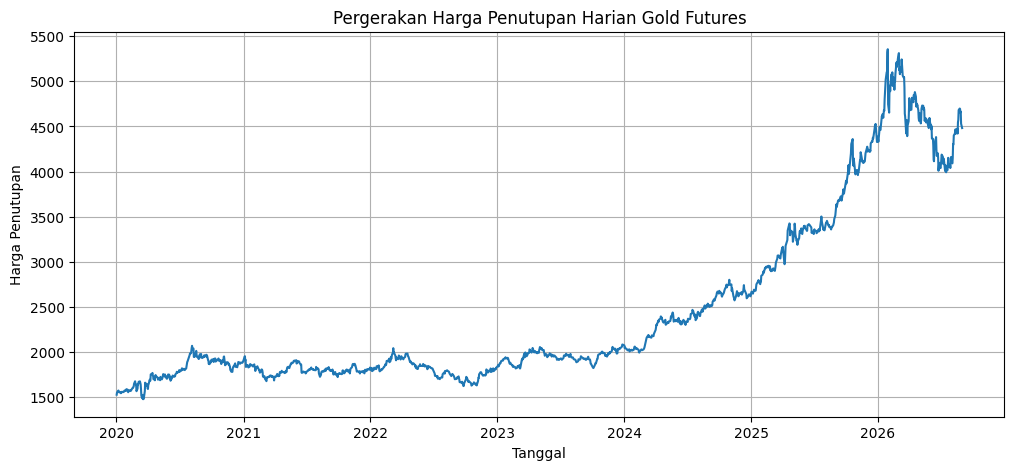

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    gold['Date'],
    gold['Close']
)

plt.title(
    'Pergerakan Harga Penutupan Harian Gold Futures'
)

plt.xlabel('Tanggal')
plt.ylabel('Harga Penutupan')

plt.grid(True)
plt.show()

##Split Data


Skema 1 (82% Train : 18% Test): total=1501, train=1230 (2020-01-02 s/d 2025-07-09), test=271 (2025-07-10 s/d 2026-08-31)
Skema 2 (87% Train : 13% Test): total=1501, train=1305 (2020-01-02 s/d 2025-11-18), test=196 (2025-11-19 s/d 2026-08-31)
Skema 3 (90% Train : 10% Test): total=1501, train=1350 (2020-01-02 s/d 2026-01-30), test=151 (2026-02-02 s/d 2026-08-31)


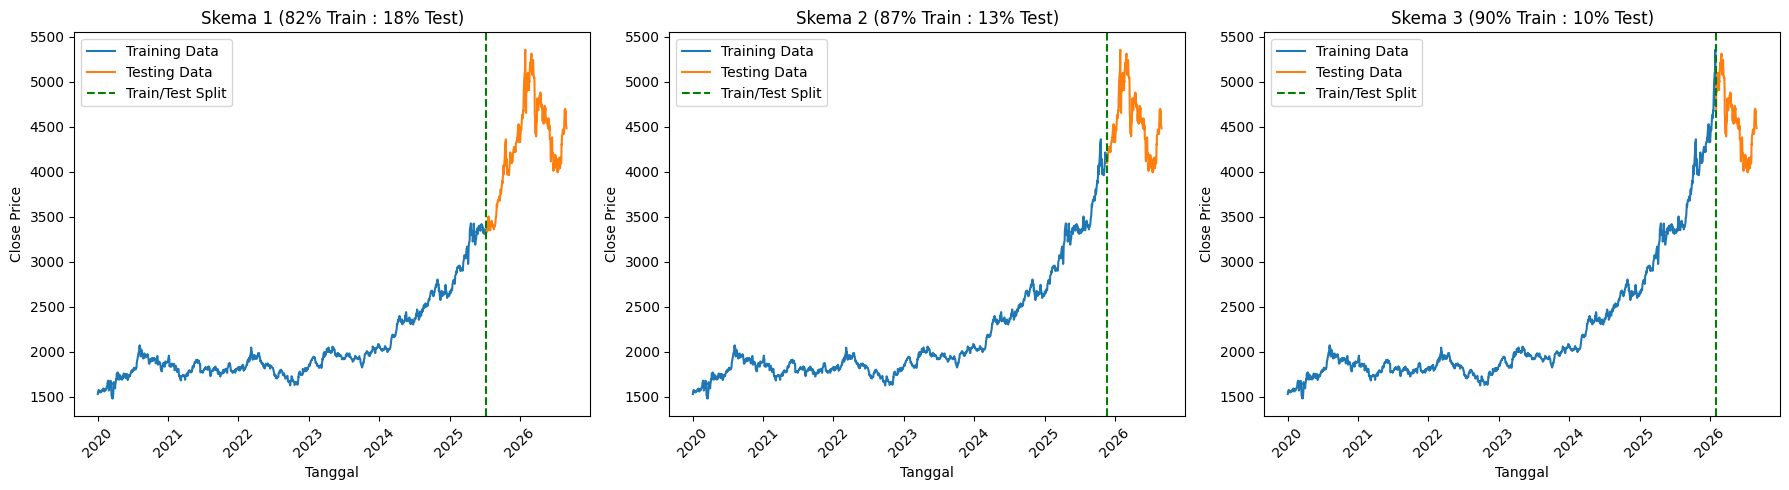

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Pastikan 'Date' berformat datetime dan dijadikan index
df = gold.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date').sort_index()

n = len(df)

# Variasikan rasio train/test pada SELURUH data hingga 2026
split_ratios = {
    "Skema 1 (82% Train : 18% Test)": 0.82,
    "Skema 2 (87% Train : 13% Test)": 0.87,
    "Skema 3 (90% Train : 10% Test)": 0.90
}

splits = {}

# Proses pembagian data berdasarkan seluruh dataset
for name, ratio in split_ratios.items():
    train_size = int(n * ratio)

    train = df.iloc[:train_size]
    test = df.iloc[train_size:]

    splits[name] = {"train": train, "test": test}

    print(f"{name}: total={n}, train={len(train)} "
          f"({train.index.min().date()} s/d {train.index.max().date()}), "
          f"test={len(test)} ({test.index.min().date()} s/d {test.index.max().date()})")

# Visualisasi grafik split data
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, sp) in zip(axes, splits.items()):
    ax.plot(sp["train"].index, sp["train"]["Close"], label="Training Data", color="tab:blue")
    ax.plot(sp["test"].index, sp["test"]["Close"], label="Testing Data", color="tab:orange")
    ax.axvline(sp["test"].index.min(), color="green", linestyle="--", label="Train/Test Split")

    ax.set_title(name)
    ax.set_xlabel("Tanggal")
    ax.set_ylabel("Close Price")
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Kestasioneran Data

In [ ]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

def adf_report(series, label=""):
    result = adfuller(series.dropna())
    stat, pval = result[0], result[1]
    status = "Stasioner" if pval <= 0.05 else "Tidak Stasioner"
    print(f"{label:35s} | ADF Stat: {stat:8.3f} | p-value: {pval:8.4f} | {status}")
    return stat, pval

adf_results = []

for name, sp in splits.items():
    train_close = sp["train"]["Close"]
    print(f"--- {name} ---")

    # Uji pada Level I(0)
    stat0, p0 = adf_report(train_close, "Close I(0)")

    # Uji setelah Differencing 1x I(1)
    stat1, p1 = adf_report(train_close.diff().dropna(), "Close I(1) - differencing 1x")

    # Penentuan orde differencing (d)
    d_order = 0 if p0 <= 0.05 else 1

    adf_results.append({
        "Skema": name,
        "ADF_I0": stat0,
        "p_I0": p0,
        "ADF_I1": stat1,
        "p_I1": p1,
        "d_terpilih": d_order
    })
    print()

# Menampilkan hasil ringkasan dalam bentuk DataFrame
adf_df = pd.DataFrame(adf_results)
adf_df

--- Skema 1 (82% Train : 18% Test) ---
Close I(0)                          | ADF Stat:    1.594 | p-value:   0.9978 | Tidak Stasioner
Close I(1) - differencing 1x        | ADF Stat:  -11.965 | p-value:   0.0000 | Stasioner

--- Skema 2 (87% Train : 13% Test) ---
Close I(0)                          | ADF Stat:    3.960 | p-value:   1.0000 | Tidak Stasioner
Close I(1) - differencing 1x        | ADF Stat:   -6.706 | p-value:   0.0000 | Stasioner

--- Skema 3 (90% Train : 10% Test) ---


/tmp/ipykernel_1015/3767900369.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna())
/tmp/ipykernel_1015/3767900369.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna())
/tmp/ipykernel_1015/3767900369.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag

Close I(0)                          | ADF Stat:    4.268 | p-value:   1.0000 | Tidak Stasioner
Close I(1) - differencing 1x        | ADF Stat:   -5.539 | p-value:   0.0000 | Stasioner



,Skema,ADF_I0,p_I0,ADF_I1,p_I1,d_terpilih
0,Skema 1 (82% Train : 18% Test),1.594465,0.997841,-11.965004,4.019646e-22,1
1,Skema 2 (87% Train : 13% Test),3.960402,1.000000,-6.706454,3.774422e-09,1
2,Skema 3 (90% Train : 10% Test),4.267544,1.000000,-5.538736,1.720878e-06,1


##ACF dan PACF Setelah tra

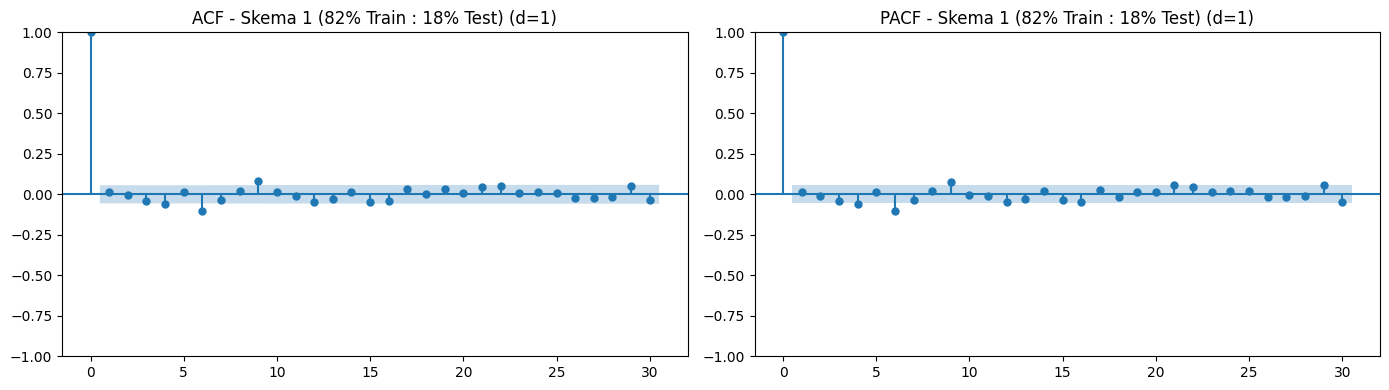

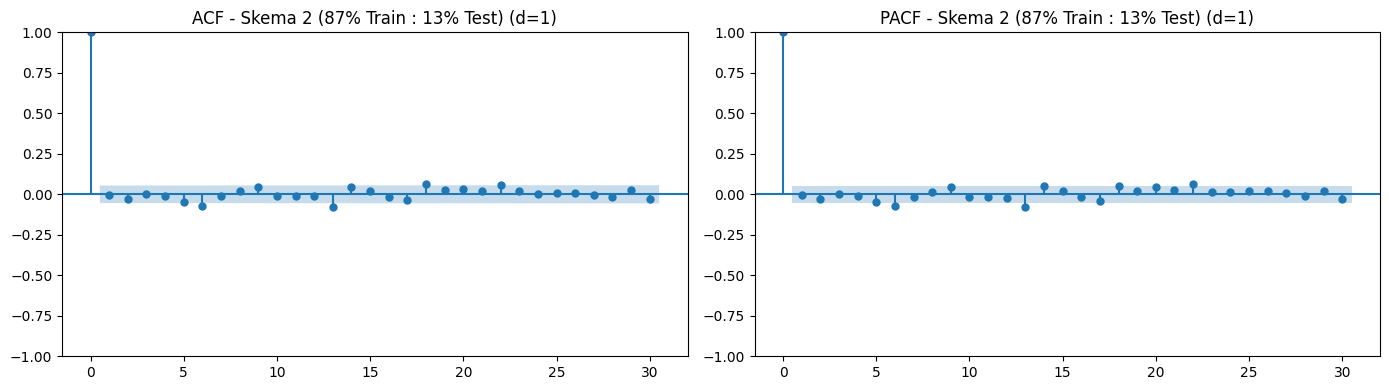

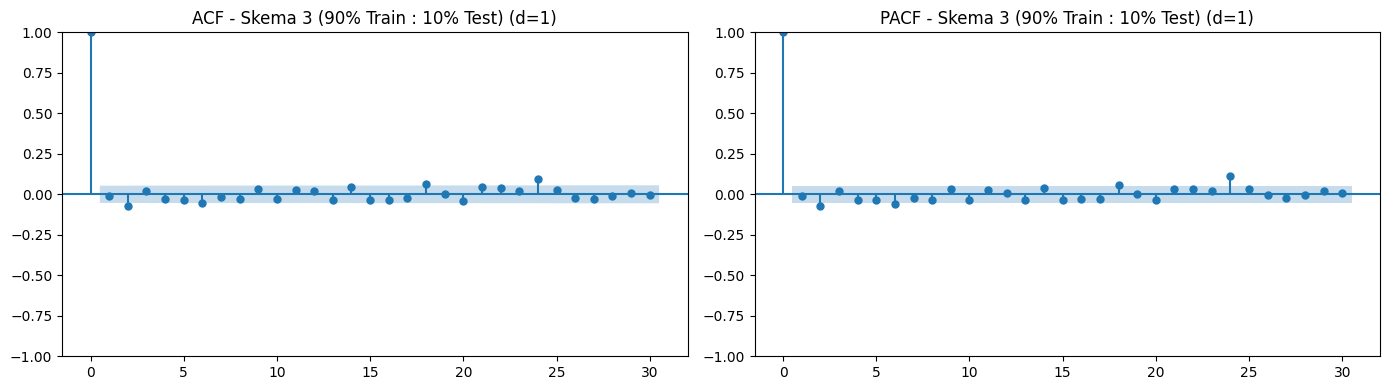

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Menggunakan data asli (tanpa log) dan nilai d dari adf_df sebelumnya
for name, sp in splits.items():
    d = adf_df.loc[adf_df["Skema"] == name, "d_terpilih"].values[0]
    series = sp["train"]["Close"]

    # Differencing 1x jika d > 0
    diff_series = series.diff(d).dropna() if d > 0 else series

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Plot ACF
    plot_acf(diff_series, lags=30, ax=axes[0])
    axes[0].set_title(f"ACF - {name} (d={d})")

    # Plot PACF
    plot_pacf(diff_series, lags=30, ax=axes[1], method="ywm")
    axes[1].set_title(f"PACF - {name} (d={d})")

    plt.tight_layout()
    plt.show()

###Kandidat Model ARIMA

In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

def grid_search_arima(series, d, p_range=range(0, 4), q_range=range(0, 4)):
    results = []
    for p in p_range:
        for q in q_range:
            if p == 0 and q == 0 and d == 0:
                continue
            try:
                model = ARIMA(series, order=(p, d, q)).fit()
                pvals = model.pvalues

                # Cek apakah semua variabel (selain konstanta) signifikan (p-value < 0.05)
                sig = all(pvals[pvals.index != "const"] < 0.05) if len(pvals) > 0 else False

                results.append({
                    "order": (p, d, q),
                    "AIC": model.aic,
                    "BIC": model.bic,
                    "all_significant": sig,
                    "model": model
                })
            except Exception:
                continue

    res_df = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
    return res_df

best_models = {}

for name, sp in splits.items():
    d = int(adf_df.loc[adf_df["Skema"] == name, "d_terpilih"].values[0])
    series = sp["train"]["Close"]

    print(f"=== Grid Search ARIMA - {name} (d={d}) ===")
    res_df = grid_search_arima(series, d)

    # Menampilkan 10 kombinasi model terbaik berdasarkan AIC
    display(res_df[["order", "AIC", "BIC", "all_significant"]].head(10))

    # Pilih model dengan AIC terendah yang signifikan; kalau tidak ada, ambil AIC terendah
    sig_candidates = res_df[res_df["all_significant"] == True]
    best_row = sig_candidates.iloc[0] if len(sig_candidates) > 0 else res_df.iloc[0]

    best_models[name] = {
        "order": best_row["order"],
        "d": d,
        "model": best_row["model"],
        "AIC": best_row["AIC"],
        "BIC": best_row["BIC"],
        "grid": res_df
    }

    print(f">>> Model terpilih {name}: ARIMA{best_row['order']} | AIC={best_row['AIC']:.3f} | BIC={best_row['BIC']:.3f}")
    print()

=== Grid Search ARIMA - Skema 1 (82% Train : 18% Test) (d=1) ===


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, fr

,order,AIC,BIC,all_significant
0,"(3, 1, 3)",11257.016646,11292.814339,True
1,"(2, 1, 3)",11259.192639,11289.876376,False
2,"(3, 1, 2)",11259.192645,11289.876382,False
3,"(0, 1, 0)",11261.711538,11266.825494,True
4,"(2, 1, 2)",11262.559248,11288.129028,True
5,"(3, 1, 1)",11263.253827,11288.823608,False
6,"(0, 1, 1)",11263.264053,11273.491965,False
7,"(1, 1, 0)",11263.264911,11273.492823,False
8,"(2, 1, 1)",11263.450542,11283.906367,True
9,"(1, 1, 3)",11263.487079,11289.056860,False


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, fr

>>> Model terpilih Skema 1 (82% Train : 18% Test): ARIMA(3, 1, 3) | AIC=11257.017 | BIC=11292.814

=== Grid Search ARIMA - Skema 2 (87% Train : 13% Test) (d=1) ===


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, fr

,order,AIC,BIC,all_significant
0,"(3, 1, 3)",12316.008449,12352.220791,False
1,"(2, 1, 2)",12316.171710,12342.037669,True
2,"(0, 1, 0)",12320.526775,12325.699967,True
3,"(2, 1, 3)",12321.317306,12352.356456,False
4,"(0, 1, 1)",12322.525408,12332.871791,False
5,"(1, 1, 0)",12322.525482,12332.871865,False
6,"(0, 1, 2)",12323.926835,12339.446410,False
7,"(2, 1, 0)",12323.931136,12339.450712,False
8,"(1, 1, 1)",12324.514858,12340.034433,False
9,"(3, 1, 0)",12325.897075,12346.589842,False


In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

overfit_results = {}

for name, info in best_models.items():
    p, d, q = info["order"]
    series = splits[name]["train"]["Close"]
    base_aic, base_bic = info["AIC"], info["BIC"]

    # Menambahkan +1 orde AR dan +1 orde MA untuk menguji overfitting
    candidates = [(p + 1, d, q), (p, d, q + 1)]
    rows = [{"order": (p, d, q), "AIC": base_aic, "BIC": base_bic, "keterangan": "Model Awal (terbaik)"}]

    for cand in candidates:
        try:
            m = ARIMA(series, order=cand).fit()
            rows.append({"order": cand, "AIC": m.aic, "BIC": m.bic, "keterangan": "Overfitting test"})
        except Exception:
            pass

    overfit_df = pd.DataFrame(rows)
    overfit_results[name] = overfit_df

    print(f"=== Uji Overfitting - {name} ===")
    display(overfit_df)
    print()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from statsmodels.graphics.tsaplots import plot_acf

diag_results = []

for name, info in best_models.items():
    model = info["model"]
    resid = model.resid

    # Uji Independensi Residual (Ljung-Box Test)
    lb_test = acorr_ljungbox(resid, lags=[10], return_df=True)
    lb_p = lb_test["lb_pvalue"].values[0]

    # Uji Normalitas Residual (Jarque-Bera Test)
    jb_stat, jb_p, skew, kurt = jarque_bera(resid)

    diag_results.append({
        "Skema": name,
        "Model": f"ARIMA{info['order']}",
        "LjungBox_p": lb_p,
        "Independen (p>0.05)": lb_p > 0.05,
        "JarqueBera_p": jb_p,
        "Normal (p>0.05)": jb_p > 0.05
    })

    # Visualisasi Residual & ACF Residual
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
    axes[0].plot(resid)
    axes[0].set_title(f"Residual Plot - {name}")

    plot_acf(resid, lags=20, ax=axes[1])
    axes[1].set_title(f"ACF Residual - {name}")

    plt.tight_layout()
    plt.show()

# Ringkasan Hasil Diagnostik
diag_df = pd.DataFrame(diag_results)
diag_df

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# 10. Forecasting pada Data Testing & Evaluasi (MAPE, MSE)
def evaluate_forecast(actual, predicted):
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    return mape, mse, rmse

eval_results = []
forecasts = {}

for name, info in best_models.items():
    train_data = splits[name]["train"]["Close"]
    test_data = splits[name]["test"]["Close"]
    order = info["order"]
    n_test = len(test_data)

    # Fit ulang model tanpa dependensi indeks agar forecast berjalan lancar
    model_temp = ARIMA(train_data.values, order=order).fit()
    fc_values = model_temp.forecast(steps=n_test)

    # Buat Series dengan indeks dari data test
    fc_mean = pd.Series(fc_values, index=test_data.index)

    mape, mse, rmse = evaluate_forecast(test_data.values, fc_mean.values)

    forecasts[name] = fc_mean
    eval_results.append({
        "Skema": name,
        "Model ARIMA": f"ARIMA{order}",
        "AIC": info["AIC"],
        "BIC": info["BIC"],
        "MAPE (%)": mape,
        "MSE": mse,
        "RMSE": rmse
    })

eval_df = pd.DataFrame(eval_results)
display(eval_df)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, info) in zip(axes, best_models.items()):
    train = splits[name]["train"]["Close"]
    test = splits[name]["test"]["Close"]
    fc = forecasts[name]

    ax.plot(train.index, train.values, label="Training Data", color="tab:blue")
    ax.plot(test.index, test.values, label="Testing Data (Actual)", color="tab:blue", linestyle="--")
    ax.plot(fc.index, fc.values, label="Forecast", color="tab:red")
    ax.axvline(test.index.min(), color="green", linestyle="--", alpha=0.7)
    ax.set_title(f"{name}\nARIMA{info['order']}")
    ax.set_xlabel("Tanggal")
    ax.set_ylabel("Close Price")
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# 11. Ringkasan Perbandingan Ketiga Skema
summary_df = eval_df.copy()
summary_df = summary_df[["Skema", "Model ARIMA", "AIC", "BIC", "MAPE (%)", "MSE", "RMSE"]]
summary_df = summary_df.round(4)
display(summary_df)

# Visualisasi Bar Chart MAPE Antar Skema
plt.figure(figsize=(8, 5))
plt.bar(summary_df["Skema"], summary_df["MAPE (%)"], color="tab:blue")
plt.title("Perbandingan MAPE ARIMA Antar Skema Data")
plt.ylabel("MAPE (%)")
plt.xticks(rotation=15)

for i, v in enumerate(summary_df["MAPE (%)"]):
    plt.text(i, v + 0.05, f"{v:.2f}%", ha="center")

plt.tight_layout()
plt.show()

In [ ]:
import os
from google.colab import files

# 1. Download file .ipynb dari sesi browser Colab ke folder /content/
print("Memproses file notebook...")
!colab-export

# 2. Cari file .ipynb yang baru saja diekspor di /content/
files_in_dir = os.listdir('/content/')
ipynb_files = [f for f in files_in_dir if f.endswith('.ipynb')]

if ipynb_files:
    target_file = ipynb_files[0]
    print(f"Mengonversi file: {target_file}")

    # 3. Konversi file .ipynb menjadi HTML utuh
    !jupyter nbconvert --to html "{target_file}"

    html_file = target_file.replace('.ipynb', '.html')

    # 4. Otomatis unduh file .html ke laptop/komputer kamu
    files.download(html_file)
    print("Selesai! File HTML sedang diunduh.")
else:
    print("Gagal menemukan file .ipynb. Coba simpan manual lewat File > Download > Download .ipynb lalu upload ke folder sisi kiri Colab.")

In [ ]:
!jupyter nbconvert --to html /content/*.ipynb

In [ ]:
import os
from google.colab import files

# Cari nama file .ipynb yang baru di-upload
files_in_dir = os.listdir('/content/')
ipynb_files = [f for f in files_in_dir if f.endswith('.ipynb')]

if ipynb_files:
    target_file = ipynb_files[0]
    # Konversi menjadi HTML utuh
    !jupyter nbconvert --to html "{target_file}"

    html_file = target_file.replace('.ipynb', '.html')
    print("Berhasil mengonversi! Mengunduh file HTML...")
    files.download(html_file)
else:
    print("File .ipynb belum ter-upload di panel kiri. Silakan upload terlebih dahulu.")